## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')#completa el código

In [ ]:
traffic.head(5)# mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head(5)# mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.


In [ ]:
traffic.info()# Examinar la estructura de traffic
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:

- Las columnas UpdateTimeUTC y UpdateTimeUTCWeekAgo son de tipo object, pero representan fechas y horas, por lo que deberían convertirse al tipo datetime para facilitar el análisis temporal y permitir extraer variables como el año.
- Respecto a los valores faltantes, no se observan datos ausentes en ninguna columna, ya que todas muestran 1,004,464 valores no nulos.

In [ ]:
eco.info()# Examinar la estructura de eco
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"



En la estructura del DF eco, se observa que:
- Las columnas City GDP/capita, Unemployment %, PM2.5 (μg/m³) y Population (M) están almacenadas como tipo object, aunque representan valores numéricos. Esto probablemente se debe a que contienen símbolos o formatos especiales, como separadores de miles, comas como decimales o el símbolo de porcentaje. Por lo tanto, estas columnas deberán limpiarse y convertirse a tipo float para permitir su análisis numérico.
- En cuanto a los valores faltantes, no se observan datos ausentes, ya que todas las columnas presentan 30 valores no nulos.


### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.



In [ ]:

# Estandarizar los nombres de las columnas de traffic
#tu código aquí

traffic = traffic.rename(columns={
    'Country': 'country',
    'UpdateTimeUTC': 'update_time_utc',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago'
})
# verificar cambios
traffic.columns


Index(['country', 'City', 'update_time_utc', 'JamsDelay', 'TrafficIndexLive',
       'JamsLengthInKms', 'JamsCount', 'TrafficIndexWeekAgo',
       'update_time_utc_week_ago', 'TravelTimeLivePer10KmsMins',
       'TravelTimeHistoricPer10KmsMins', 'MinsDelay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco = eco.rename(columns={
    'Country': 'country'
})
# verificar cambios
eco.columns

Index(['Year', 'City', 'country', 'City GDP/capita', 'Unemployment %',
       'PM2.5 (μg/m³)', 'Population (M)'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.



In [ ]:

# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'],errors='coerce',utc=True)#tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'],errors='coerce',utc=True)#tu código aquí

# verificar el cambio
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype              
---  ------                          --------------    -----              
 0   country                         1004464 non-null  object             
 1   City                            1004464 non-null  object             
 2   update_time_utc                 1004464 non-null  datetime64[ns, UTC]
 3   JamsDelay                       1004464 non-null  float64            
 4   TrafficIndexLive                1004464 non-null  float64            
 5   JamsLengthInKms                 1004464 non-null  float64            
 6   JamsCount                       1004464 non-null  float64            
 7   TrafficIndexWeekAgo             1004464 non-null  float64            
 8   update_time_utc_week_ago        1004464 non-null  datetime64[ns, UTC]
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
eco['City GDP/capita'] = eco['City GDP/capita'].astype(str) \
    .str.replace('.', '', regex=False) \
    .str.replace(',', '.', regex=False) \
    .astype(float)

# Limpia porcentaje de desempleo
eco['Unemployment %'] = eco['Unemployment %'].astype(str) \
    .str.replace('%', '', regex=False) \
    .str.replace(',', '.', regex=False) \
    .astype(float)

# Limpia población en millones
eco['Population (M)'] = eco['Population (M)'].astype(str) \
    .str.replace(',', '.', regex=False) \
    .astype(float)

# Calcula población total
eco['population'] = eco['Population (M)'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             30 non-null     int64  
 1   City             30 non-null     object 
 2   country          30 non-null     object 
 3   City GDP/capita  30 non-null     float64
 4   Unemployment %   30 non-null     float64
 5   PM2.5 (μg/m³)    30 non-null     object 
 6   Population (M)   30 non-null     float64
 7   population       30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,Year,City,country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M),population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.


In [ ]:
# Extraer el año de las fechas en update_time_utc
# traffic['year'] = ...
traffic['year'] = traffic['update_time_utc'].dt.year
# Verificar cambio
traffic.head(3)

,country,City,update_time_utc,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,update_time_utc_week_ago,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024

traffic_2024 = traffic[traffic['year'] == 2024].copy()

eco_2024 = eco[eco['Year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

,country,City,update_time_utc,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,update_time_utc_week_ago,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,Year,City,country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M),population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.



In [ ]:
traffic_city_year_2024 = traffic_2024.groupby(
    ["City","country","year"]
)[[
    "JamsDelay",
    "TrafficIndexLive",
    "JamsLengthInKms",
    "JamsCount",
    "MinsDelay",
    "TravelTimeLivePer10KmsMins",
    "TravelTimeHistoricPer10KmsMins"
]].mean().reset_index()

traffic_city_year_2024.head()

,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
# tu código aquí
traffic_city_year_2024.sort_values(["JamsDelay"], ascending=False)

,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es... mexico-city


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.



In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['City','country','year','JamsDelay','TrafficIndexLive',
             'JamsLengthInKms','JamsCount','MinsDelay',
             'TravelTimeLivePer10KmsMins','TravelTimeHistoricPer10KmsMins']

right_cols = ['City','Year','City GDP/capita','Unemployment %','PM2.5 (μg/m³)','Population (M)']


# Usar .copy() para crear datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()

eco_2024_small = eco_2024[right_cols].copy()


# Unir datasets usando ciudad y año
merged = traffic_2024_small.merge(
    eco_2024_small,
    left_on=['City','year'],
    right_on=['City','Year'],
    how='inner'
)


# Mostrar las primeras 5 filas
merged.head()

,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,Year,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,2024,11124.0,9.5,"16,80",6.1
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,2024,11442.0,10.0,"17,60",11.3
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,2024,16251.0,7.8,"12,80",4.8
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,2024,18117.0,7.2,"14,50",15.4
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,2024,12381.0,8.2,"13,50",3.7



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

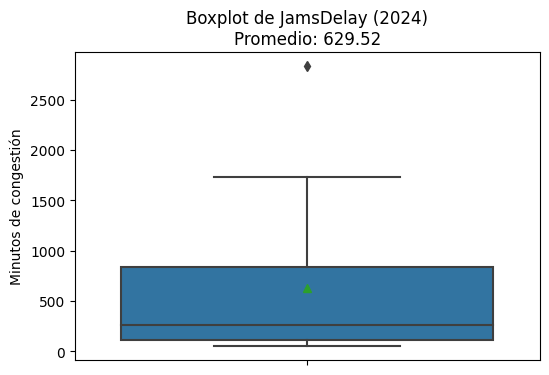

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestión
plt.figure(figsize=(6,4))

sns.boxplot(data=merged, y='JamsDelay', showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['JamsDelay'].mean()

plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.ylabel('Minutos de congestión')
plt.xlabel('')

plt.show()

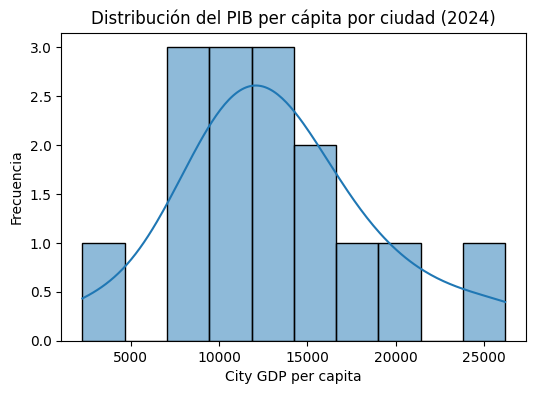

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(data=merged, x='City GDP/capita', bins=10, kde=True)

plt.title('Distribución del PIB per cápita por ciudad (2024)')
plt.xlabel('City GDP per capita')
plt.ylabel('Frecuencia')

plt.show()

<Figure size 1000x500 with 0 Axes>

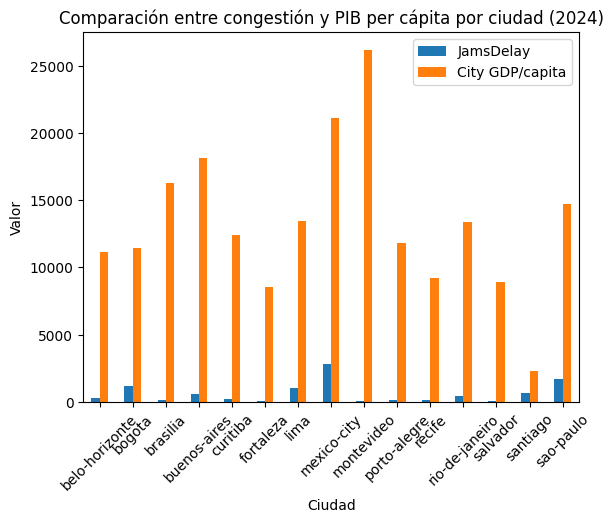

In [ ]:
plt.figure(figsize=(10,5))

merged.plot(
    x='City',
    y=['JamsDelay','City GDP/capita'],
    kind='bar'
)

plt.title('Comparación entre congestión y PIB per cápita por ciudad (2024)')
plt.xlabel('Ciudad')
plt.ylabel('Valor')

plt.xticks(rotation=45)

plt.show()


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).


🧾 Resumen ejecutivo
Contexto & objetivo

El objetivo de este análisis fue explorar la relación entre la movilidad urbana y la productividad económica en distintas ciudades durante 2024. En particular, se buscó identificar si mayores niveles de congestión vehicular, medidos a través de indicadores como JamsDelay y tiempos de viaje, se relacionan con diferencias en la productividad económica representada por el PIB per cápita de la ciudad. Estas variables son relevantes porque la congestión puede impactar la eficiencia económica, los costos logísticos y la calidad de vida urbana.

Cobertura de datos

El análisis se realizó utilizando datos correspondientes al año 2024, integrando información de movilidad urbana proveniente de registros de tráfico y datos económicos provenientes de indicadores urbanos. El dataset final incluye múltiples ciudades de distintos países, donde cada observación representa el promedio anual de indicadores de tráfico por ciudad combinado con métricas económicas y ambientales.

Metodología (alto nivel)

Primero se realizó un proceso de limpieza y estandarización de datos, corrigiendo formatos de fecha, nombres de columnas y tipos de datos para asegurar consistencia entre datasets. Posteriormente se agregaron los datos de tráfico para obtener promedios anuales por ciudad y año, reduciendo la granularidad diaria a una visión más estratégica. Después se integraron los datasets de movilidad y economía mediante una unión INNER utilizando las variables ciudad y año, garantizando que solo se analizaran registros presentes en ambas fuentes. Finalmente se realizaron visualizaciones exploratorias como boxplots, histogramas y gráficos comparativos para identificar distribuciones, posibles valores atípicos y tendencias generales entre las variables.

Hallazgos iniciales

Los resultados sugieren que no existe una relación lineal clara entre el PIB per cápita y los niveles de congestión urbana. Algunas ciudades con altos niveles de productividad económica también presentan niveles elevados de congestión, posiblemente debido a mayor actividad económica y densidad urbana. Sin embargo, también se identificaron ciudades con niveles moderados de congestión y economías fuertes, lo que podría reflejar una mejor planificación urbana o infraestructura de transporte más eficiente. Asimismo, algunos valores extremos en congestión sugieren posibles diferencias en infraestructura vial o sistemas de transporte público.

Recomendaciones

Con base en los patrones observados, Lima aparece como una ciudad prioritaria para análisis adicional, ya que combina niveles elevados de congestión con indicadores económicos relativamente más bajos en comparación con otras ciudades analizadas. Esto sugiere que la congestión podría estar afectando la eficiencia económica y la movilidad urbana. Se recomienda profundizar el análisis incorporando variables adicionales como densidad poblacional, infraestructura de transporte público y crecimiento urbano, así como validar los datos con fuentes complementarias. Desde una perspectiva de política pública, ciudades con estas características podrían beneficiarse de inversiones en transporte público, optimización de infraestructura vial y estrategias de movilidad sostenible para mejorar tanto la productividad como la calidad de vida urbana.